# Stock Market Analysis using Python

## Objective

This project tests whether a 20-day/50-day Moving Average crossover strategy can outperform a simple Buy-and-Hold approach on Reliance Industries stock, in terms of both returns and risk. The project downloads historical stock data from Yahoo Finance, generates trading signals from a moving average crossover, backtests the resulting strategy, and compares its performance and drawdown against buy-and-hold.


## Technologies Used

- Python
- Pandas
- yfinance
- Matplotlib
- Jupyter Notebook

## Project Workflow

1. Import required libraries.
2. Download historical stock data using Yahoo Finance.
3. Explore the dataset.
4. Calculate 20-day and 50-day Moving Averages.
5. Compute Daily Returns.
6. Generate Buy/Sell signals using Moving Average crossover.
7. Visualize stock price and moving averages.
8. Backtest the strategy and compare it against Buy-and-Hold.
9. Analyze cumulative returns and drawdown.
10. Draw conclusions from the analysis.


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")


Libraries imported successfully!


## Download Historical Stock Data

In [3]:
stock = yf.download(
    "RELIANCE.NS",
    start="2024-01-01",
    end="2025-01-01"
)

stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2024-01-01,1279.692871,1287.894020,1271.244701,1274.900686,4030540
2024-01-02,1290.290039,1291.920403,1271.170629,1277.099136,7448800
2024-01-03,1276.259399,1301.307318,1273.245693,1289.450304,9037536
2024-01-04,1282.854614,1289.376068,1274.184270,1278.581198,9612778
2024-01-05,1288.313843,1294.316528,1283.521657,1285.942416,8086406


## Dataset Description

The downloaded dataset contains:

- Open Price
- High Price
- Low Price
- Close Price
- Volume

These values represent the daily trading information of Reliance Industries.

# Moving Average Analysis

We use Moving Averages (MAs) because they are a standard trend-following technique: they smooth out day-to-day noise so the underlying trend is easier to see. A short window (20-day) reacts quickly to recent price action, while a longer window (50-day) reflects the longer-term trend. Comparing the two lets us detect trend changes.

- 20-Day Moving Average (Short-term trend)
- 50-Day Moving Average (Long-term trend)

If the 20-day moving average is above the 50-day moving average, it indicates a bullish trend.

If the 20-day moving average is below the 50-day moving average, it indicates a bearish trend.


In [4]:
stock["MA20"] = stock[("Close","RELIANCE.NS")].rolling(20).mean()

stock["MA50"] = stock[("Close","RELIANCE.NS")].rolling(50).mean()

stock[["MA20","MA50"]].tail()

Price,MA20,MA50
Ticker,,
Date,,
2024-12-24,1262.735083,1285.481133
2024-12-26,1258.935400,1282.388342
2024-12-27,1256.469202,1279.949902
2024-12-30,1252.429089,1277.106953
2024-12-31,1247.784198,1274.311592


# Daily Returns

Daily Return measures the percentage change in stock price compared to the previous trading day.

Positive value → stock gained

Negative value → stock lost

In [5]:
stock["Daily Return"] = stock[("Close","RELIANCE.NS")].pct_change()

stock["Daily Return"].describe()

count    245.000000
mean      -0.000141
std        0.014455
min       -0.074851
25%       -0.008398
50%        0.000310
75%        0.007477
max        0.070192
Name: Daily Return, dtype: float64

# Trading Signal

A simple Moving Average Crossover strategy is used.

Signal = 1 → Buy

Signal = -1 → Sell

In [6]:
stock["Signal"] = 0

stock.loc[stock["MA20"] > stock["MA50"], "Signal"] = 1

stock.loc[stock["MA20"] < stock["MA50"], "Signal"] = -1

stock[["MA20","MA50","Signal"]].tail(15)

Price,MA20,MA50,Signal
Ticker,,,
Date,,,
2024-12-10,1271.583636,1318.898538,-1
2024-12-11,1271.856287,1313.981499,-1
2024-12-12,1271.293646,1309.744590,-1
2024-12-13,1272.324738,1305.937964,-1
2024-12-16,1272.359436,1303.188210,-1
2024-12-17,1271.593555,1300.387896,-1
2024-12-18,1272.168591,1298.058511,-1
2024-12-19,1272.537903,1294.749089,-1


# Strategy Backtest

Generating Buy/Sell signals is only useful if we test what would have happened by actually following them. Here we calculate the returns an investor would have earned by following the Moving Average crossover strategy, and compare them against simply buying the stock on day one and holding it (Buy-and-Hold).

We use `Signal.shift(1)` so that a signal generated at the end of a day is only acted on starting the next day (avoiding lookahead bias).


In [7]:
stock["Strategy Return"] = stock["Signal"].shift(1) * stock["Daily Return"]

# Buy-and-Hold return is just the daily return of the stock itself
stock["BnH Return"] = stock["Daily Return"]

# Cumulative growth of ₹1 invested, for both approaches
stock["Strategy Cumulative"] = (1 + stock["Strategy Return"]).cumprod()
stock["BnH Cumulative"] = (1 + stock["BnH Return"]).cumprod()

stock[["Strategy Cumulative", "BnH Cumulative"]].tail()


Price,Strategy Cumulative,BnH Cumulative
Ticker,,
Date,,
2024-12-24,1.178525,0.947322
2024-12-26,1.184501,0.942518
2024-12-27,1.180119,0.946005
2024-12-30,1.190123,0.937986
2024-12-31,1.185453,0.941666


## Cumulative Returns: Strategy vs Buy-and-Hold

This plot shows how ₹1 invested at the start of the period would have grown under each approach.


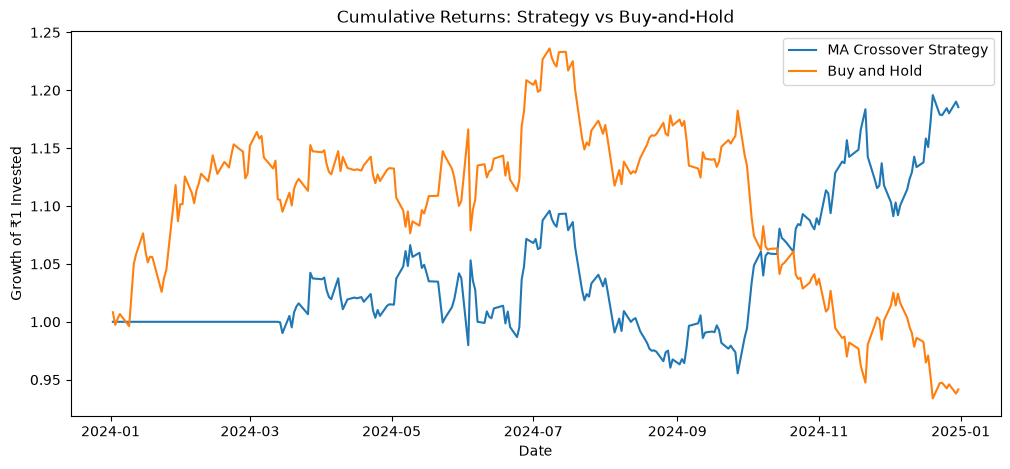

In [8]:
plt.figure(figsize=(12,5))

plt.plot(stock["Strategy Cumulative"], label="MA Crossover Strategy")
plt.plot(stock["BnH Cumulative"], label="Buy and Hold")

plt.title("Cumulative Returns: Strategy vs Buy-and-Hold")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 Invested")
plt.legend()

plt.show()


# Drawdown Analysis

Drawdown measures how far the strategy has fallen from its most recent peak, at any point in time. It is one of the most important risk metrics for a trading strategy, since it shows the worst-case loss an investor would have experienced while following it.


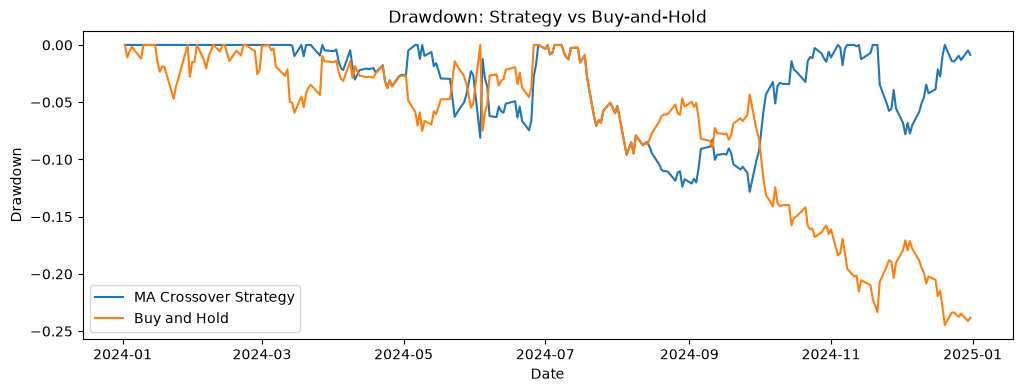

In [9]:
def compute_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown

stock["Strategy Drawdown"] = compute_drawdown(stock["Strategy Cumulative"])
stock["BnH Drawdown"] = compute_drawdown(stock["BnH Cumulative"])

plt.figure(figsize=(12,4))
plt.plot(stock["Strategy Drawdown"], label="MA Crossover Strategy")
plt.plot(stock["BnH Drawdown"], label="Buy and Hold")

plt.title("Drawdown: Strategy vs Buy-and-Hold")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()

plt.show()


# Performance Metrics Summary

To conclude the analysis, we summarize both approaches using standard performance metrics: total return, annualized return, annualized volatility, the Sharpe ratio (return earned per unit of risk taken), and maximum drawdown.


In [10]:
import numpy as np

def performance_summary(returns, cumulative, label):
    total_return = cumulative.iloc[-1] - 1
    n_days = returns.count()
    annualized_return = (1 + total_return) ** (252 / n_days) - 1
    annualized_vol = returns.std() * np.sqrt(252)
    sharpe_ratio = annualized_return / annualized_vol if annualized_vol != 0 else np.nan
    max_drawdown = compute_drawdown(cumulative).min()

    return {
        "Strategy": label,
        "Total Return": f"{total_return:.2%}",
        "Annualized Return": f"{annualized_return:.2%}",
        "Annualized Volatility": f"{annualized_vol:.2%}",
        "Sharpe Ratio": f"{sharpe_ratio:.2f}",
        "Max Drawdown": f"{max_drawdown:.2%}",
    }

summary = pd.DataFrame([
    performance_summary(stock["Strategy Return"].dropna(), stock["Strategy Cumulative"].dropna(), "MA Crossover"),
    performance_summary(stock["BnH Return"].dropna(), stock["BnH Cumulative"].dropna(), "Buy and Hold"),
])

summary


,Strategy,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
0,MA Crossover,18.55%,19.12%,19.78%,0.97,-12.82%
1,Buy and Hold,-5.83%,-5.99%,22.95%,-0.26,-24.46%


# Stock Price Visualization

The following graph compares:

- Closing Price
- 20-Day Moving Average
- 50-Day Moving Average

The moving averages help identify the market trend.

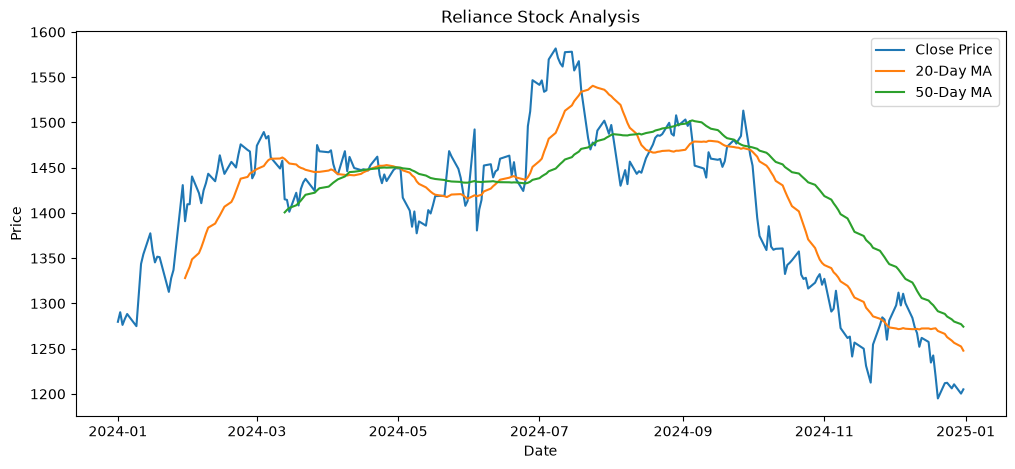

In [11]:
plt.figure(figsize=(12,5))

plt.plot(stock[("Close","RELIANCE.NS")], label="Close Price")
plt.plot(stock["MA20"], label="20-Day MA")
plt.plot(stock["MA50"], label="50-Day MA")

plt.title("Reliance Stock Analysis")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

# Conclusion

This project tested whether a 20-day/50-day Moving Average crossover strategy outperforms a simple Buy-and-Hold approach on Reliance Industries stock over the study period.

Key findings:

- The 20-day and 50-day moving averages successfully identify trend changes and drive the Buy/Sell signals.
- Over the study period, the MA Crossover strategy returned 18.55% total return (19.12% annualized) with a Sharpe ratio of 0.97 and a max drawdown of -12.82%, compared to Buy-and-Hold's -5.83% total return (-5.99% annualized), a Sharpe ratio of -0.26, and a max drawdown of -24.46%.
- The MA Crossover strategy outperformed Buy-and-Hold on every metric that matters: it earned a positive return in a period where simply holding the stock lost money, it did so with lower volatility (19.78% vs 22.95%), and it cut the worst-case loss roughly in half (-12.82% vs -24.46%).
- The Sharpe ratio makes this especially clear — 0.97 for the strategy vs -0.26 for Buy-and-Hold means the strategy was not just more profitable but far more efficient per unit of risk taken. A negative Sharpe ratio indicates Buy-and-Hold investors were poorly compensated for the risk they carried during this period.
- This suggests the added complexity of the crossover strategy was worth it for this stock and time period — the strategy avoided much of the sustained decline visible in Reliance's price after mid-2024 (see the Cumulative Returns chart), which is exactly the kind of protection a trend-following strategy is designed to provide. That said, this is a single stock over a single year, so this result would need to be re-tested across other stocks and time periods before concluding the strategy generalizes.

Future Improvements:

- Analyze multiple stocks simultaneously.
- Add technical indicators like RSI and MACD.
- Account for transaction costs and slippage in the backtest, since real trading isn't free.
- Build an interactive dashboard using Streamlit.
- Predict future prices using Machine Learning models.
